In [1]:
print("Hello")

Hello


Defaulting to user installation because normal site-packages is not writeable


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ---------------------------------------- 1.8/1.8 MB 5.9 MB/s eta 0:00:00


In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.colors as colors
import seaborn as sns
import itertools
from scipy.stats import norm
import scipy.stats
from sklearn.naive_bayes import GaussianNB
%matplotlib inline
sns.set()



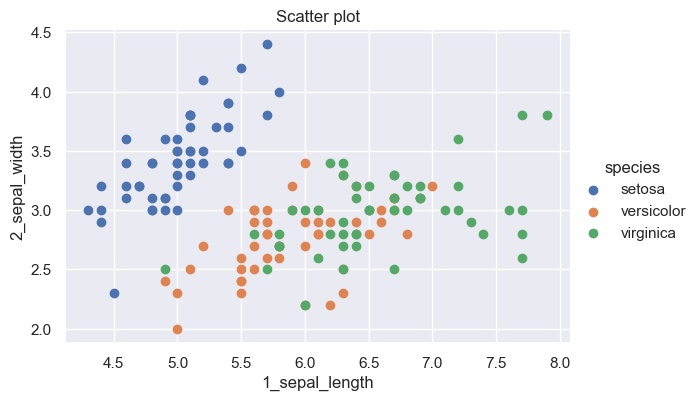

In [4]:
#Load the data set
iris = sns.load_dataset("iris")
iris = iris.rename(index = str, columns = {'sepal_length':'1_sepal_length','sepal_width':'2_sepal_width', 'petal_length':'3_petal_length', 'petal_width':'4_petal_width'})
#Plot the scatter of sepal length vs sepal width
sns.FacetGrid(iris, hue="species",height= 4, aspect= 1.5) .map(plt.scatter,"1_sepal_length", "2_sepal_width", ) .add_legend()
plt.title('Scatter plot')
df1 = iris[["1_sepal_length", "2_sepal_width",'species']]

In [11]:
def predict_NB_gaussian_class(X,mu_list,std_list,pi_list):
#Returns the class for which the Gaussian Naive Bayes objective function has greatest v
    scores_list = []
    classes = len(mu_list)
    for p in range(classes):
        score = (norm.pdf(x = X[0], loc = mu_list[p][0][0], scale = std_list[p][0][0] )
        * norm.pdf(x = X[1], loc = mu_list[p][0][1], scale = std_list[p][0][1] )* pi_list[p])
        scores_list.append(score)
    return np.argmax(scores_list)

def predict_Bayes_class(X,mu_list,sigma_list):
#Returns the predicted class from an optimal bayes classifier - distributions must be known
    scores_list = []
    classes = len(mu_list)
    for p in range(classes):
        score = scipy.stats.multivariate_normal.pdf(X, mean=mu_list[p], cov=sigma_list[p])
        scores_list.append(score)
    return np.argmax(scores_list)

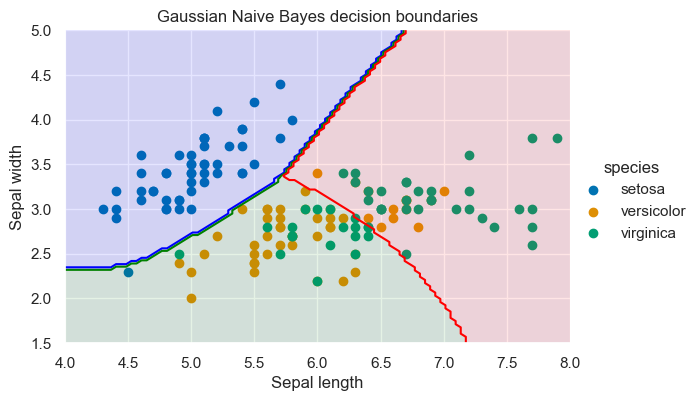

In [12]:
#Estimating the parameters
mu_list = np.split(df1.groupby('species').mean().values,[1,2])
std_list = np.split(df1.groupby('species').std().values,[1,2], axis = 0)
pi_list = df1.iloc[:,2].value_counts().values / len(df1)
# Our 2-dimensional distribution will be over variables X and Y
N = 100
X = np.linspace(4, 8, N)
Y = np.linspace(1.5, 5, N)
X, Y = np.meshgrid(X, Y)
#fig = plt.figure(figsize = (10,10))
#ax = fig.gca()
color_list = ['Blues','Greens','Reds']
my_norm = colors.Normalize(vmin=-1.,vmax=1.)
g = sns.FacetGrid(iris, hue="species", height= 4, aspect=1.5, palette = 'colorblind') .map(plt.scatter, "1_sepal_length", "2_sepal_width",) .add_legend()
my_ax = g.ax
#Computing the predicted class function for each value on the grid
zz = np.array( [predict_NB_gaussian_class( np.array([xx,yy]).reshape(-1,1), mu_list, std_list, pi_list)
    for xx, yy in zip(np.ravel(X), np.ravel(Y)) ] )
#Reshaping the predicted class into the meshgrid shape
Z = zz.reshape(X.shape)
#Plot the filled and boundary contours
my_ax.contourf( X, Y, Z, 2, alpha = .1, colors = ('blue','green','red'))
my_ax.contour( X, Y, Z, 2, alpha = 1, colors = ('blue','green','red'))
# Addd axis and title
my_ax.set_xlabel('Sepal length')
my_ax.set_ylabel('Sepal width')
my_ax.set_title('Gaussian Naive Bayes decision boundaries')
plt.show()

C:\Users\PC\AppData\Local\Temp\ipykernel_19508\425731173.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_labels = df1.iloc[:,2].replace({'setosa':0,'versicolor':1,'virginica':2}).copy()
C:\Users\PC\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
C:\Users\PC\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
C:\Users\PC\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GaussianNB was fitt

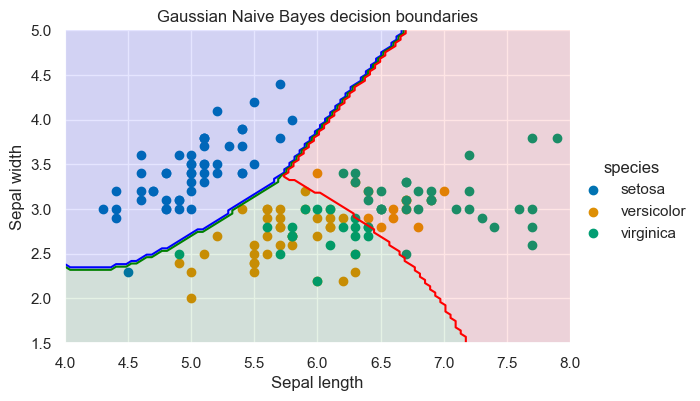

In [15]:
from sklearn.naive_bayes import GaussianNB
#Setup X and y data
X_data = df1.iloc[:,0:2]
y_labels = df1.iloc[:,2].replace({'setosa':0,'versicolor':1,'virginica':2}).copy()
#Fit model
model_sk = GaussianNB(priors = None)
model_sk.fit(X_data,y_labels)
# Our 2-dimensional classifier will be over variables X and Y
N = 100
X = np.linspace(4, 8, N)
Y = np.linspace(1.5, 5, N)
X, Y = np.meshgrid(X, Y)
#fig = plt.figure(figsize = (10,10))
#ax = fig.gca()
color_list = ['Blues','Greens','Reds']
my_norm = colors.Normalize(vmin=-1.,vmax=1.)
g = sns.FacetGrid(iris, hue="species", height= 4, aspect= 1.5, palette = 'colorblind') .map(plt.scatter, "1_sepal_length", "2_sepal_width",) .add_legend()
my_ax = g.ax
#Computing the predicted class function for each value on the grid
zz = np.array( [model_sk.predict( [[xx,yy]])[0] for xx, yy in zip(np.ravel(X), np.ravel(Y)
) ] )
#Reshaping the predicted class into the meshgrid shape
Z = zz.reshape(X.shape)
#Plot the filled and boundary contours
my_ax.contourf( X, Y, Z, 2, alpha = .1, colors = ('blue','green','red'))
my_ax.contour( X, Y, Z, 2, alpha = 1, colors = ('blue','green','red'))
# Addd axis and title
my_ax.set_xlabel('Sepal length')
my_ax.set_ylabel('Sepal width')
my_ax.set_title('Gaussian Naive Bayes decision boundaries')
plt.show()

In [16]:
print(iris)

     1_sepal_length  2_sepal_width  3_petal_length  4_petal_width    species
0               5.1            3.5             1.4            0.2     setosa
1               4.9            3.0             1.4            0.2     setosa
2               4.7            3.2             1.3            0.2     setosa
3               4.6            3.1             1.5            0.2     setosa
4               5.0            3.6             1.4            0.2     setosa
..              ...            ...             ...            ...        ...
145             6.7            3.0             5.2            2.3  virginica
146             6.3            2.5             5.0            1.9  virginica
147             6.5            3.0             5.2            2.0  virginica
148             6.2            3.4             5.4            2.3  virginica
149             5.9            3.0             5.1            1.8  virginica

[150 rows x 5 columns]


In [22]:
df2 = iris[['1_sepal_length', '2_sepal_width', '3_petal_length',  '4_petal_width','species']]

x_data = df2.iloc[:,0:4]
ylabels = df2.iloc[:,4].replace({'setosa':0,'versicolor':1,'virginica':2}).copy()

C:\Users\PC\AppData\Local\Temp\ipykernel_19508\3030950142.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ylabels = df2.iloc[:,4].replace({'setosa':0,'versicolor':1,'virginica':2}).copy()


In [27]:
#Estimating the parameters
mu_list = np.split(df2.groupby('species').mean().values,[1,2])
std_list = np.split(df2.groupby('species').std().values,[1,2], axis = 0)
pi_list = df2.iloc[:,4].value_counts().values / len(df2)
mu_list, std_list, pi_list

([array([[5.006, 3.428, 1.462, 0.246]]),
  array([[5.936, 2.77 , 4.26 , 1.326]]),
  array([[6.588, 2.974, 5.552, 2.026]])],
 [array([[0.35248969, 0.37906437, 0.173664  , 0.10538559]]),
  array([[0.51617115, 0.31379832, 0.46991098, 0.19775268]]),
  array([[0.63587959, 0.32249664, 0.5518947 , 0.27465006]])],
 array([0.33333333, 0.33333333, 0.33333333]))

In [28]:
def predict_NB_gaussian_class(X,mu_list,std_list,pi_list):
#Returns the class for which the Gaussian Naive Bayes objective function has greatest value
    scores_list = []
    classes = len(mu_list)
    for p in range(classes):
        score = (norm.pdf(x = X[0], loc = mu_list[p][0][0], scale = std_list[p][0][0] )
        * norm.pdf(x = X[1], loc = mu_list[p][0][1], scale = std_list[p][0][1] )
        * norm.pdf(x = X[2], loc = mu_list[p][0][2], scale = std_list[p][0][2] )
        * norm.pdf(x = X[3], loc = mu_list[p][0][3], scale = std_list[p][0][3] )
        * pi_list[p])
        scores_list.append(score)
        
    return np.argmax(scores_list)

In [30]:
X = np.array(df2.iloc[:, 0:4])

In [31]:
y_labels = df2.iloc[:,4].replace({'setosa':0,'versicolor':1,'virginica':2}).copy()

C:\Users\PC\AppData\Local\Temp\ipykernel_19508\849662219.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_labels = df2.iloc[:,4].replace({'setosa':0,'versicolor':1,'virginica':2}).copy()


In [32]:
y_pred = np.zeros(X.shape[0])
for i in range(X.shape[0]):
    y_pred[i] = predict_NB_gaussian_class( X[i], mu_list, std_list, pi_list)
y_pred

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
       1., 2., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 2., 1., 1., 1., 1., 1., 1., 2., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 2., 2.,
       2., 2., 2., 2., 1., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       1., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 1., 2., 2.,
       2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.])

In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
accuracy_score(y_pred, y_labels)

0.96

Ví dụ 2

In [34]:
import numpy as np
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Đọc tệp dữ liệu Cancer.csv trong file data_cancer
df = pd.read_csv('C:/Users/PC/OneDrive/Desktop/Học máy/23000104_Nguyễn Hữu Dũng_Naive_Bayes/breast-cancer-wisconsin.data', header=None, na_values='?')

df = df.dropna()

print(df.head() )

        0   1   2   3   4   5     6   7   8   9   10
0  1000025   5   1   1   1   2   1.0   3   1   1   2
1  1002945   5   4   4   5   7  10.0   3   2   1   2
2  1015425   3   1   1   1   2   2.0   3   1   1   2
3  1016277   6   8   8   1   3   4.0   3   7   1   2
4  1017023   4   1   1   3   2   1.0   3   1   1   2


In [35]:
# Tách dữ liệu Test ,Chọn 80 mẫu lành tính (Trường phân loại là 2) và 40 mẫu ác tính (Trường phân loại là 4) làm dữ liệu Test, còn lại là dữ liệu Training

#Lấy ngẫu nhiên 80 mẫu lành tính mà cột "Loai" là 2
test_benign = df[df.iloc[: ,10] == 2].sample(80)

#Lấy ngẫu nhiên 40 mẫu ác tính mà cột "Loai" là 4
test_malignant = df[df.iloc[:, 10] == 4].sample(40)

test_sample = pd.concat([test_benign, test_malignant])

In [36]:
#Estimating the parameters
mu_list = np.split(df.groupby(10).mean().iloc[:,1:10].values,[1])
std_list = np.split(df.groupby(10).std().iloc[:,1:10].values,[1], axis = 0)
pi_list = df.iloc[:, 10].value_counts().values / len(df)

mu_list, std_list, pi_list

([array([[2.96396396, 1.30630631, 1.41441441, 1.34684685, 2.10810811,
          1.34684685, 2.08333333, 1.26126126, 1.06531532]]),
  array([[7.18828452, 6.57740586, 6.56066946, 5.58577406, 5.32635983,
          7.62761506, 5.9748954 , 5.85774059, 2.60251046]])],
 [array([[1.67266121, 0.8556575 , 0.95703142, 0.91708832, 0.87711153,
          1.1778482 , 1.06229942, 0.95460591, 0.50973781]]),
  array([[2.43790721, 2.72424378, 2.569104  , 3.19663139, 2.44308657,
          3.116679  , 2.28242221, 3.34887613, 2.56449456]])],
 array([0.65007321, 0.34992679]))

In [37]:
#classifier function
def predict_NB_gaussian_class2(X, mu_list, std_list, pi_list):
    #Returns the class for which the Gaussian Naive Bayes objective function has greatest value
    scores_list = []
    classes = len(mu_list)
    for k in range(classes):
        score = np.log(pi_list[k])
        for i in range(len(X)):
            score += np.log(norm.pdf(x=X[i], loc=mu_list[k][0][i], scale=std_list[k][0][i]))
        scores_list.append(score)
    return np.argmax(scores_list)

In [38]:
y_labels2 = test_sample.iloc[:,10].replace({2:0,4:1}.copy())
y_labels2

577    0
624    0
29     0
240    0
28     0
      ..
610    1
340    1
414    1
483    1
329    1
Name: 10, Length: 120, dtype: int64

In [39]:
y_pred2 = np.zeros(test_sample.shape[0])
for i in range(test_sample.shape[0]):
    y_pred2[i] = predict_NB_gaussian_class2( test_sample.iloc[i,1:10].values, mu_list, std_list, pi_list)
y_pred2

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1.])

In [40]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
accuracy_score(y_pred2, y_labels2)

0.9583333333333334

B. PHƯƠNG PHÁP NÄIVE BAYES CHO DỮ LIỆU RỜI RẠC

In [41]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score

data = pd.read_csv('C:/Users/PC/OneDrive/Desktop/Học máy/23000104_Nguyễn Hữu Dũng_Naive_Bayes/multinomial_nb_orders (1).csv')

print(data.head())

      cuisine     city device user_segment    promo fav_ingredient  \
0    american  city_16    web          new  promo_1          onion   
1        thai  city_10    ios       family  promo_7       cilantro   
2    american  city_18    ios      student  promo_1         cheese   
3    japanese  city_10    web       family  promo_3         ginger   
4  vietnamese  city_10    web       family     none     fish_sauce   

  spice_level day_of_week price_bucket  
0         hot         Wed         high  
1        mild         Wed          mid  
2         hot         Fri          mid  
3        mild         Tue         high  
4        mild         Wed          low  


In [42]:
target_feature = "cuisine"
Y = data[target_feature]

labels = np.zeros((len(set(Y)), 2), dtype=Y.dtype)

id = 0
for label in set(Y):
    labels[id, 0] = label
    labels[id, 1] = (Y == label).sum()/len(Y)
    id += 1

In [43]:
def get_distinct_value_in_fields():
    column_name_index = data.columns
    tmp_list = column_name_index.values
    num_nomials_per_fields = np.zeros((len(tmp_list), 2), dtype=tmp_list.dtype)
    
    num_nomials_per_fields[:, 0] = tmp_list
    
    for i in range(len(tmp_list)):
        X = data[tmp_list[i]]
        unique_elements = set(X)
        num_nomials_per_fields[i,1] = len(unique_elements)
    return num_nomials_per_fields

In [44]:
def Pxik_feature_per_class(X, xi, nums_nomials_M, alpha = 1.0):
    X = np.array(X)
    count = (X == xi).sum()
    
    return (count + alpha)/(len(X) + nums_nomials_M*alpha)

In [45]:
def predict_output_label(X, x_input, p_labels, target_feature):
    num_labels_M = get_distinct_value_in_fields()
    
    p =np.log(np.array(p_labels[:, 1], dtype=float))
    
    for k in range(len(p)):
        Xk = X[X[target_feature] == p_labels[k, 0]]
        
        for i in range(len(x_input)):
            p[k] += np.log(Pxik_feature_per_class(Xk.iloc[:, i + 1], x_input.iloc[i], num_labels_M[i+1,1]))
    
    y_star = np.argmax(p)
    return p_labels[y_star, 0]

In [46]:
Train_size = round(len(data) * 0.6)
X_train = data[:Train_size]
Y_train = data[target_feature][:Train_size]

X_test = data[Train_size:].drop(target_feature, axis=1).reset_index(drop=True, inplace=False)
Y_test = data[target_feature][Train_size:].reset_index(drop=True, inplace=False)

Y_pred = np.zeros(len(Y_test), dtype=Y_test.dtype)

print(len(X_test), len(Y_test))
print(X_test.index, Y_test.index)

for i in range(len(X_test)):
    Y_pred[i] = predict_output_label(X_train, X_test.iloc[i,:], labels, target_feature)

1200 1200
RangeIndex(start=0, stop=1200, step=1) RangeIndex(start=0, stop=1200, step=1)


In [47]:
print(f'Accuracy: {accuracy_score(Y_pred, Y_test):.4f}')
print(predict_output_label(X_train, X_train.iloc[14, 1:], labels, target_feature))

Accuracy: 0.4733
mediterranean


Bài 5

In [49]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score

df2 = pd.read_csv('C:/Users/PC/OneDrive/Desktop/Học máy/23000104_Nguyễn Hữu Dũng_Naive_Bayes/bernoulli_nb_symptoms.csv')
df2.head(5)

,condition,fever,chills,runny_nose,sneezing,cough,sore_throat,headache,nausea,vomiting,...,dehydration_signs,dry_mouth,dark_urine,rapid_heart_rate,sweating,itchy_eyes,watery_eyes,nasal_congestion,postnasal_drip,joint_pain
0,food_poison,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,flu,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,flu,0,0,0,0,1,0,0,0,0,...,0,1,0,1,0,0,0,1,0,1
3,stomach_bug,0,0,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,food_poison,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [50]:
target_col = "condition"

Y = df2[target_col]

labels = np.zeros((len(set(Y)), 2), dtype = Y.dtype)
id = 0
for label in set(Y):
    labels[id, 0] = label
    labels[id, 1] = (Y == label).sum()/len(Y)
    id += 1
labels

array([['stomach_bug', np.float64(0.1236)],
       ['cold', np.float64(0.1576)],
       ['migraine', np.float64(0.0936)],
       ['food_poison', np.float64(0.1064)],
       ['dehydration', np.float64(0.094)],
       ['allergy', np.float64(0.1184)],
       ['covid_like', np.float64(0.1532)],
       ['flu', np.float64(0.1532)]], dtype=object)

In [51]:
def Pik_feature_per_class_bernoulli(X):
    X = np.array(X)
    count = (X == 1).sum()
    return count/len(X)

In [52]:
def predict_output_label(X, x_input, p_labels, target_col):
    p = np.log(np.array(p_labels[:, 1], dtype=float))
    for k in range(len(p)):
        Xk = X[X[target_col] == p_labels[k, 0]]
        
        for i in range(len(x_input)):
            Pik = Pik_feature_per_class_bernoulli(Xk.iloc[:, i+1])
            if(Pik != 0):
                p[k] += np.log(x_input.iloc[i] * Pik + (1 - x_input.iloc[i]) * (1 - Pik) )
    
    y_star = np.argmax(p)
    return p_labels[y_star, 0]

In [53]:
Train_size = round(len(df2) * 0.6)
X_train = df2[:Train_size]
Y_train = df2[target_col][:Train_size]

X_test = df2[Train_size:].drop(target_col, axis=1).reset_index(drop=True, inplace=False)
Y_test = df2[target_col][Train_size:].reset_index(drop=True, inplace=False)

Y_pred = np.zeros(len(Y_test), dtype=Y_test.dtype)

print(len(X_test), len(Y_test))

for i in range(len(X_test)):
    Y_pred[i] = predict_output_label(X_train, X_test.iloc[i,:], labels, target_col)
Y_pred

1000 1000


array(['migraine', 'food_poison', 'cold', 'stomach_bug', 'migraine',
       'migraine', 'cold', 'flu', 'flu', 'stomach_bug', 'stomach_bug',
       'flu', 'allergy', 'cold', 'cold', 'stomach_bug', 'covid_like',
       'dehydration', 'cold', 'food_poison', 'allergy', 'food_poison',
       'food_poison', 'allergy', 'stomach_bug', 'migraine', 'flu',
       'covid_like', 'food_poison', 'cold', 'flu', 'cold', 'cold', 'flu',
       'stomach_bug', 'cold', 'stomach_bug', 'food_poison', 'migraine',
       'cold', 'cold', 'allergy', 'covid_like', 'covid_like', 'flu',
       'flu', 'dehydration', 'cold', 'cold', 'allergy', 'dehydration',
       'cold', 'stomach_bug', 'covid_like', 'allergy', 'cold', 'flu',
       'food_poison', 'allergy', 'food_poison', 'flu', 'allergy',
       'allergy', 'allergy', 'allergy', 'food_poison', 'flu', 'flu',
       'cold', 'stomach_bug', 'food_poison', 'food_poison', 'flu',
       'food_poison', 'flu', 'allergy', 'migraine', 'cold', 'cold',
       'covid_like', 'cold

In [54]:
print(f'Accuracy: {accuracy_score(Y_pred, Y_test):.4f}')
print(predict_output_label(X_train, X_train.iloc[19, 1:], labels, target_col))

Accuracy: 0.4790
food_poison
